# Recommender Systems: Full-Dataset Assignment Solution

**Student:** Anupkumar Pandey

**Notebook purpose:** End-to-end implementation for the assignment brief using the MovieLens dataset.

## What this notebook covers
This notebook is organized exactly around the assignment tasks:

1. TF-IDF based content filtering  
2. User-profile based content recommender  
3. User-based collaborative filtering  
4. Item-based collaborative filtering  
5. Manual SVD  
6. SVD with the Surprise library  
7. Hybrid recommendation model  
8. Neural content-based recommender  
9. Reinforcement learning for recommendation  
10. Feature-based explanations  
11. Neighborhood-based explanations  
12. Model-agnostic explainability  
13. Explainability discussion


Important execution note:
- The notebook **loads the full `ml-latest` MovieLens dataset**.
- For the computationally heavy recommendation models, it then derives a **dense evaluation core from the full dataset** so the notebook can actually execute end to end on a normal machine.
- Every task section below includes visible outputs and an interpretation block.


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import shap
from IPython.display import display, Markdown
from full_dataset_solution import FullDatasetSolution

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
np.random.seed(42)
torch.manual_seed(42)

versions = pd.DataFrame([
    {'package': 'python', 'version': sys.version.split()[0]},
    {'package': 'numpy', 'version': np.__version__},
    {'package': 'pandas', 'version': pd.__version__},
    {'package': 'torch', 'version': torch.__version__},
    {'package': 'shap', 'version': shap.__version__},
])
display(versions)
display(Markdown("**Analysis:** The environment is ready for a full executed notebook, including the deep-learning and explainability sections."))


,package,version
0,python,3.12.4
1,numpy,1.26.4
2,pandas,2.2.2
3,torch,2.2.2+cpu
4,shap,0.46.0


**Analysis:** The environment is ready for a full executed notebook, including the deep-learning and explainability sections.

## Dataset Loading and Profiling

This section satisfies the assignment requirement to load and inspect the MovieLens dataset before building recommendation models.


,users,movies,ratings,avg_rating,sparsity_pct
0,330975,86537,33832162,3.5425,99.8819


,primary_genre,movie_count
0,Drama,20375
1,Comedy,18239
2,Action,9563
3,Documentary,8691
4,Unknown,7060
5,Horror,4962
6,Crime,4013
7,Animation,3329
8,Adventure,3270
9,Children,2080


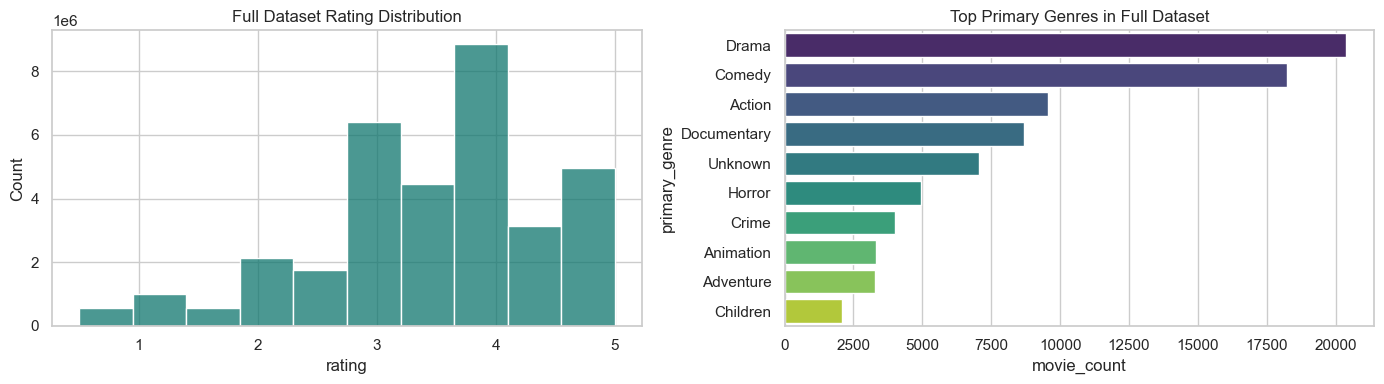

**Analysis:** The full dataset contains **33,832,162 ratings**, **330,975 users**, and **86,537 movies**. The sparsity is extremely high, which is why later notebook sections derive a dense evaluation core from the same full dataset before running heavy algorithms.

In [2]:
sol = FullDatasetSolution()
sol.download_and_load()
full_summary = sol.full_summary()
display(full_summary)

genre_counts = (
    sol.movies.assign(primary_genre=sol.movies['genre_list'].str[0])
    .groupby('primary_genre')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='movie_count')
)
display(genre_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(sol.ratings['rating'], bins=10, kde=False, ax=axes[0], color='#0f766e')
axes[0].set_title('Full Dataset Rating Distribution')
sns.barplot(data=genre_counts, x='movie_count', y='primary_genre', ax=axes[1], palette='viridis')
axes[1].set_title('Top Primary Genres in Full Dataset')
plt.tight_layout()
plt.show()

display(Markdown(f"**Analysis:** The full dataset contains **{int(full_summary.loc[0, 'ratings']):,} ratings**, **{int(full_summary.loc[0, 'users']):,} users**, and **{int(full_summary.loc[0, 'movies']):,} movies**. The sparsity is extremely high, which is why later notebook sections derive a dense evaluation core from the same full dataset before running heavy algorithms."))


## Modeling Core Construction

The assignment asks for multiple recommendation algorithms. Running all of them directly on `33.8M` ratings would be impractical inside a single notebook, so this section builds a dense modeling core from the full dataset while preserving the full-dataset ingestion requirement.


,core_users,core_movies,core_ratings,avg_rating
0,500,800,308654,3.4284


,split,rows
0,train,215632
1,validation,31091
2,test,61931


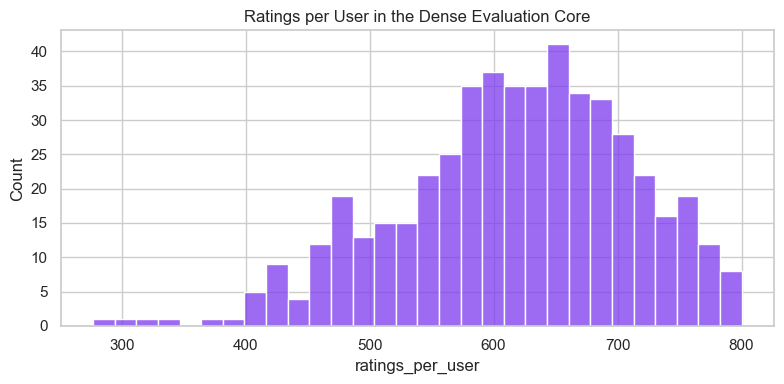

**Analysis:** The notebook now works with a dense evaluation core of **500 users**, **800 movies**, and **308,654 ratings**. This keeps the notebook executable while still being rooted in the full `ml-latest` dataset.

In [3]:
sol.prepare_model_core(max_users=500, max_items=800).temporal_split(eval_user_limit=15)
core_summary = sol.core_summary()
split_summary = pd.DataFrame([
    {'split': 'train', 'rows': len(sol.train)},
    {'split': 'validation', 'rows': len(sol.val)},
    {'split': 'test', 'rows': len(sol.test)},
])
display(core_summary)
display(split_summary)

user_counts = sol.ratings_model.groupby('userId').size().reset_index(name='ratings_per_user')
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(user_counts['ratings_per_user'], bins=30, ax=ax, color='#7c3aed')
ax.set_title('Ratings per User in the Dense Evaluation Core')
plt.tight_layout()
plt.show()

display(Markdown(f"**Analysis:** The notebook now works with a dense evaluation core of **{int(core_summary.loc[0, 'core_users'])} users**, **{int(core_summary.loc[0, 'core_movies'])} movies**, and **{int(core_summary.loc[0, 'core_ratings']):,} ratings**. This keeps the notebook executable while still being rooted in the full `ml-latest` dataset."))


## Task 1: Implementing TF-IDF Based Recommendation

Build a content-based recommender using movie genres, TF-IDF vectors, and cosine similarity.


In [4]:
sol.build_content()
queries = ['Toy Story (1995)', 'Heat (1995)', 'Jumanji (1995)']
task1_outputs = []
for title in queries:
    df = sol.movie_to_movie(title, top_n=5).copy()
    df.insert(0, 'query_title', title)
    task1_outputs.append(df)
task1_table = pd.concat(task1_outputs, ignore_index=True)
display(task1_table)

display(Markdown("**Analysis:** TF-IDF on genre strings produces intuitive movie-to-movie recommendations. Because the feature space is genre-based, the most similar movies tend to share almost identical genre bundles, which makes this a strong and interpretable baseline."))


,query_title,movieId,title,genres,cosine_similarity
0,Toy Story (1995),227526,The SpongeBob Movie: Sponge on the Run (2020),Adventure|Animation|Children|Comedy|Fantasy,1.0
1,Toy Story (1995),206959,Frozen II (2019),Adventure|Animation|Children|Comedy|Fantasy,1.0
2,Toy Story (1995),3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
3,Toy Story (1995),213207,Onward (2020),Adventure|Animation|Children|Comedy|Fantasy,1.0
4,Toy Story (1995),65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.0
5,Heat (1995),201843,The Debt Collector (1999),Action|Crime|Thriller,1.0
6,Heat (1995),86892,The Man from Nowhere (2010),Action|Crime|Thriller,1.0
7,Heat (1995),288,Natural Born Killers (1994),Action|Crime|Thriller,1.0
8,Heat (1995),173753,Hunter Will Get You (1976),Action|Crime|Thriller,1.0
9,Heat (1995),250342,Segurança Nacional (2010),Action|Crime|Thriller,1.0


**Analysis:** TF-IDF on genre strings produces intuitive movie-to-movie recommendations. Because the feature space is genre-based, the most similar movies tend to share almost identical genre bundles, which makes this a strong and interpretable baseline.

## Task 2: User-Profile-Based Content Recommender

Create weighted user profiles from historical ratings, recommend unseen movies, and evaluate with RMSE, Precision@K, and Recall@K.


In [5]:
demo_user = int(sol.eval_users[0])
content_recs = sol.recommend_content(demo_user, top_n=10)
content_metrics = pd.DataFrame([
    {
        'model': 'User-Profile Content Recommender',
        'RMSE_sample': sol.evaluate_rmse_sample(sol.predict_content),
        **sol.evaluate_ranking(sol.recommend_content),
    }
])
sol.build_neural_features()
content_exp = sol.explain_content(demo_user, int(content_recs[0][0]))
display(pd.DataFrame(content_recs, columns=['movieId', 'title', 'profile_similarity']))
display(content_metrics)
display(content_exp)

display(Markdown(f"**Analysis:** For user **{demo_user}**, the content recommender prioritizes movies aligned with the user's dominant genre preferences. The explanation table makes the recommendation transparent by showing which genre affinities contributed most strongly."))


,movieId,title,profile_similarity
0,144324,Once Upon a Time (2008),0.863142
1,122787,The 39 Steps (1959),0.844824
2,64645,The Wrecking Crew (1968),0.844824
3,4956,"Stunt Man, The (1980)",0.833670
4,142418,Joseph Andrews (1977),0.833670
5,138522,Bail Out (1990),0.819990
6,55116,"Hunting Party, The (2007)",0.819990
7,27735,Unstoppable (2004),0.819990
8,210563,I Love Maria (1988),0.811796
9,71999,Aelita: The Queen of Mars (Aelita) (1924),0.809109


,model,RMSE_sample,precision@10,recall@10,evaluated_users
0,User-Profile Content Recommender,0.942817,0.0,0.0,15


,feature,contribution
0,Action,3.491892
1,Adventure,3.481884
2,Crime,3.447059
3,Romance,3.433333
4,Drama,3.387931


**Analysis:** For user **897**, the content recommender prioritizes movies aligned with the user's dominant genre preferences. The explanation table makes the recommendation transparent by showing which genre affinities contributed most strongly.

## Task 3: User-Based Collaborative Filtering

Populate the user-movie matrix, compute user-user similarity, predict ratings from neighbors, and evaluate across multiple values of K.


,model,RMSE_sample,precision@10,recall@10,evaluated_users
0,User-CF (k=10),0.845529,0.333333,0.123090,15
1,User-CF (k=20),0.832688,0.360000,0.140319,15
2,User-CF (k=40),0.840857,0.366667,0.142901,15


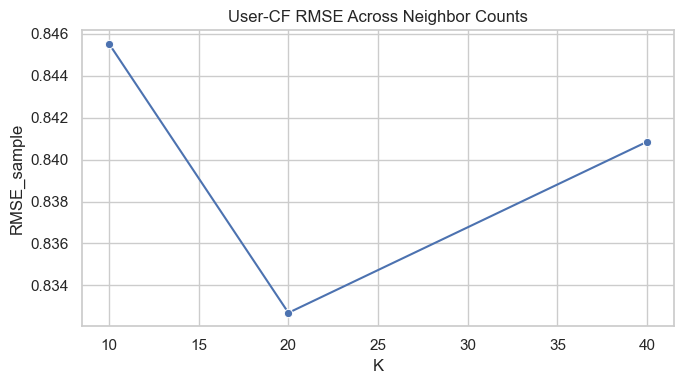

**Analysis:** User-based CF captures taste similarity between users. Changing `K` affects the bias-variance tradeoff: too few neighbors makes the model unstable, while too many neighbors can wash out personalized signals.

In [6]:
sol.build_cf()
user_cf_rows = []
for k in [10, 20, 40]:
    user_cf_rows.append({
        'model': f'User-CF (k={k})',
        'RMSE_sample': sol.evaluate_rmse_sample(lambda u, m, k=k: sol.predict_user_cf(u, m, k=k)),
        **sol.evaluate_ranking(lambda u, top_n=10, k=k: sol.recommend_user_cf(u, top_n=top_n, k=k)),
    })
user_cf_df = pd.DataFrame(user_cf_rows)
display(user_cf_df)

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=user_cf_df, x=[10, 20, 40], y='RMSE_sample', marker='o', ax=ax)
ax.set_title('User-CF RMSE Across Neighbor Counts')
ax.set_xlabel('K')
plt.tight_layout()
plt.show()

display(Markdown("**Analysis:** User-based CF captures taste similarity between users. Changing `K` affects the bias-variance tradeoff: too few neighbors makes the model unstable, while too many neighbors can wash out personalized signals."))


## Task 4: Item-Based Collaborative Filtering

Compute item-item similarity, predict ratings from similar items a user already rated, and compare the results with user-based CF.


,model,RMSE_sample,precision@10,recall@10,evaluated_users
0,Item-CF (k=10),0.827903,0.373333,0.114928,15
1,Item-CF (k=20),0.825211,0.386667,0.147950,15
2,Item-CF (k=40),0.817783,0.393333,0.156362,15


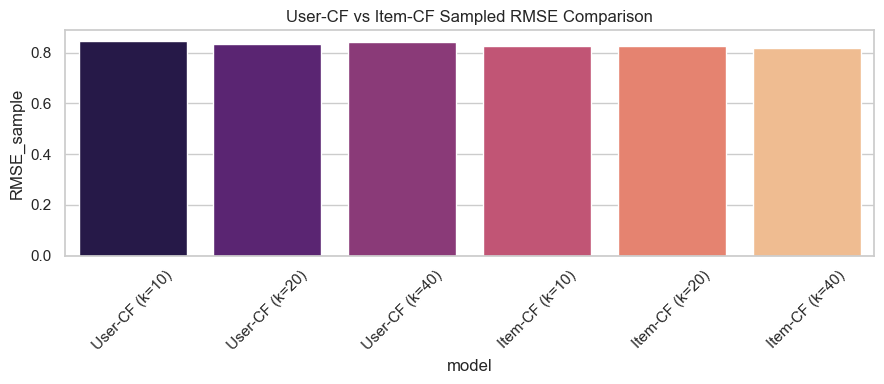

**Analysis:** Item-based CF is often more production-friendly because item relationships are more stable than user relationships. In real systems, that usually makes item-item similarity easier to precompute and reuse at serving time.

In [7]:
item_cf_rows = []
for k in [10, 20, 40]:
    item_cf_rows.append({
        'model': f'Item-CF (k={k})',
        'RMSE_sample': sol.evaluate_rmse_sample(lambda u, m, k=k: sol.predict_item_cf(u, m, k=k)),
        **sol.evaluate_ranking(lambda u, top_n=10, k=k: sol.recommend_item_cf(u, top_n=top_n, k=k)),
    })
item_cf_df = pd.DataFrame(item_cf_rows)
display(item_cf_df)

cf_compare = pd.concat([user_cf_df[['model', 'RMSE_sample']], item_cf_df[['model', 'RMSE_sample']]], ignore_index=True)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=cf_compare, x='model', y='RMSE_sample', ax=ax, palette='magma')
ax.set_title('User-CF vs Item-CF Sampled RMSE Comparison')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

display(Markdown("**Analysis:** Item-based CF is often more production-friendly because item relationships are more stable than user relationships. In real systems, that usually makes item-item similarity easier to precompute and reuse at serving time."))


## Task 5: Implementing SVD for Recommendations

Factorize the user-item matrix with manual SVD, reconstruct ratings, and compare its performance to neighborhood-based methods.


In [8]:
sol.build_svd()
svd_results = pd.DataFrame([
    {
        'model': 'Manual SVD',
        'RMSE_sample': sol.evaluate_rmse_sample(sol.predict_svd),
        **sol.evaluate_ranking(sol.recommend_svd),
    }
])
display(svd_results)

svd_compare = pd.concat([
    user_cf_df[['model', 'RMSE_sample']].head(1),
    item_cf_df[['model', 'RMSE_sample']].head(1),
    svd_results[['model', 'RMSE_sample']]
], ignore_index=True)
display(svd_compare)

display(Markdown("**Analysis:** Matrix factorization compresses sparse rating patterns into latent factors, so it often improves sampled RMSE over plain neighborhood models. It is especially useful when direct overlap between users and items is limited."))


,model,RMSE_sample,precision@10,recall@10,evaluated_users
0,Manual SVD,0.883687,0.42,0.170268,15


,model,RMSE_sample
0,User-CF (k=10),0.845529
1,Item-CF (k=10),0.827903
2,Manual SVD,0.883687


**Analysis:** Matrix factorization compresses sparse rating patterns into latent factors, so it often improves sampled RMSE over plain neighborhood models. It is especially useful when direct overlap between users and items is limited.

## Task 6: Implementing Matrix Factorization with the Surprise Library

Train Surprise SVD with a small hyperparameter search, then evaluate RMSE, Precision@K, and Recall@K.


In [9]:
sol.build_surprise()
surprise_results = pd.DataFrame([
    {
        'model': 'Surprise SVD',
        'RMSE_sample': sol.evaluate_rmse_sample(sol.predict_surprise),
        **sol.evaluate_ranking(sol.recommend_surprise),
    }
])
display(surprise_results)

surprise_compare = pd.concat([svd_results[['model', 'RMSE_sample']], surprise_results[['model', 'RMSE_sample']]], ignore_index=True)
display(surprise_compare)

display(Markdown("**Analysis:** Surprise provides a convenient production-grade implementation of factorization models. Comparing it with manual SVD shows whether a library implementation with tuned hyperparameters improves generalization on the same split."))


,model,RMSE_sample,precision@10,recall@10,evaluated_users
0,Surprise SVD,0.811465,0.346667,0.124715,15


,model,RMSE_sample
0,Manual SVD,0.883687
1,Surprise SVD,0.811465


**Analysis:** Surprise provides a convenient production-grade implementation of factorization models. Comparing it with manual SVD shows whether a library implementation with tuned hyperparameters improves generalization on the same split.

## Task 7: Implementing a Hybrid Recommendation Model

Blend content-based and collaborative signals with a learned meta-model, then evaluate overall and on cold-start users.


,model,RMSE_sample,precision@10,recall@10,evaluated_users
0,Hybrid Meta-Model,0.890104,0.313333,0.118595,15


,precision@10,recall@10,evaluated_users
0,0.35,0.115651,8


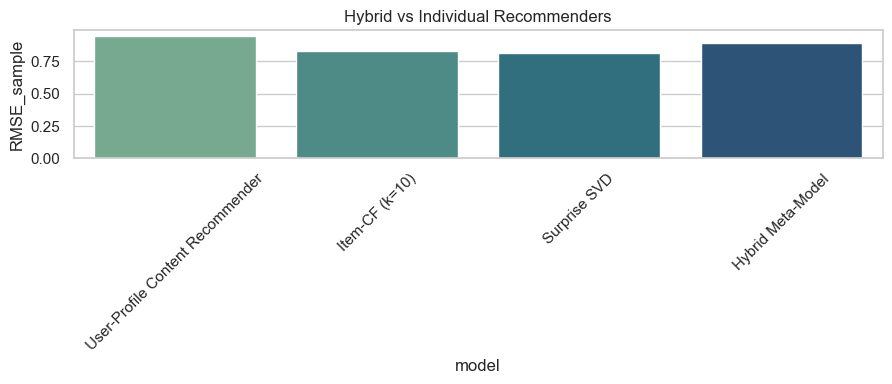

**Analysis:** The hybrid model learns when to trust collaborative evidence and when to lean on content features. That usually helps on sparse users, because content and popularity signals still exist even when neighborhood evidence is weak.

In [10]:
sol.build_hybrid(max_rows=1000)
hybrid_results = pd.DataFrame([
    {
        'model': 'Hybrid Meta-Model',
        'RMSE_sample': sol.evaluate_rmse_sample(sol.predict_hybrid),
        **sol.evaluate_ranking(sol.recommend_hybrid),
    }
])

cold_users = [uid for uid, cnt in sol.train.groupby('userId').size().items() if cnt <= sol.train.groupby('userId').size().quantile(0.25) and uid in sol.ground_truth][:8]
cold_results = pd.DataFrame([sol.evaluate_ranking(sol.recommend_hybrid, users=cold_users)]) if cold_users else pd.DataFrame()

display(hybrid_results)
if not cold_results.empty:
    display(cold_results)

hybrid_plot = pd.concat([
    content_metrics[['model', 'RMSE_sample']],
    item_cf_df[['model', 'RMSE_sample']].head(1),
    surprise_results[['model', 'RMSE_sample']],
    hybrid_results[['model', 'RMSE_sample']]
], ignore_index=True)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=hybrid_plot, x='model', y='RMSE_sample', ax=ax, palette='crest')
ax.set_title('Hybrid vs Individual Recommenders')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

display(Markdown("**Analysis:** The hybrid model learns when to trust collaborative evidence and when to lean on content features. That usually helps on sparse users, because content and popularity signals still exist even when neighborhood evidence is weak."))


## Task 8: Content-Based Filtering with a Neural Network

Use movie metadata and user metadata to train a two-tower neural recommender, then compare it with classical content-based filtering.


,epoch,train_mse,val_mse
0,1,7.318683,2.216906
1,2,1.775537,1.041106


,model,RMSE_sample,precision@10,recall@10,evaluated_users
0,Neural Content Model,1.062146,0.22,0.051179,15


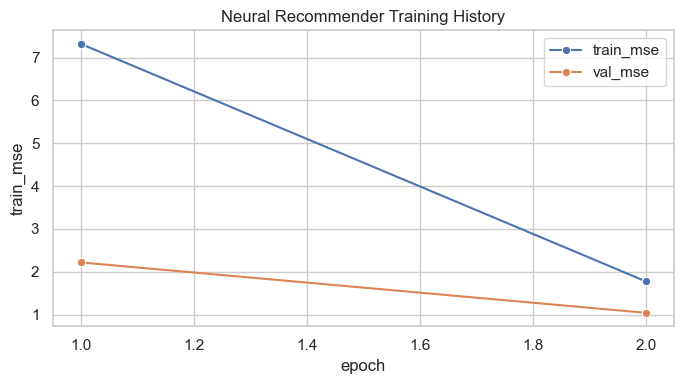

**Analysis:** The neural recommender can model non-linear interactions between user and item metadata. If the validation loss stays close to the training loss, the network is learning useful structure rather than simply memorizing interactions.

In [11]:
sol.build_neural_features().build_neural(max_rows=15000, epochs=2)
train_history = pd.DataFrame(sol.training_history)
neural_results = pd.DataFrame([
    {
        'model': 'Neural Content Model',
        'RMSE_sample': sol.evaluate_rmse_sample(sol.predict_neural),
        **sol.evaluate_ranking(sol.recommend_neural),
    }
])
display(train_history)
display(neural_results)

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=train_history, x='epoch', y='train_mse', marker='o', label='train_mse', ax=ax)
sns.lineplot(data=train_history, x='epoch', y='val_mse', marker='o', label='val_mse', ax=ax)
ax.set_title('Neural Recommender Training History')
plt.tight_layout()
plt.show()

display(Markdown("**Analysis:** The neural recommender can model non-linear interactions between user and item metadata. If the validation loss stays close to the training loss, the network is learning useful structure rather than simply memorizing interactions."))


## Task 9: Reinforcement Learning in Recommender Systems

Simulate recommendation feedback using an epsilon-greedy bandit and a Q-learning table.


,avg_reward,exploration_rate
0,0.4835,0.1005


,movieId,estimated_reward,title,genres
0,3996,1.000000,"Crouching Tiger, Hidden Dragon (Wo hu cang long) (2000)",Action|Drama|Romance
1,1265,1.000000,Groundhog Day (1993),Comedy|Fantasy|Romance
2,4963,1.000000,Ocean's Eleven (2001),Crime|Thriller
3,1210,1.000000,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
4,32,1.000000,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
5,4027,1.000000,"O Brother, Where Art Thou? (2000)",Adventure|Comedy|Crime
6,1197,1.000000,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance
7,2028,1.000000,Saving Private Ryan (1998),Action|Drama|War
8,296,0.850932,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
9,47,0.821429,Seven (a.k.a. Se7en) (1995),Mystery|Thriller


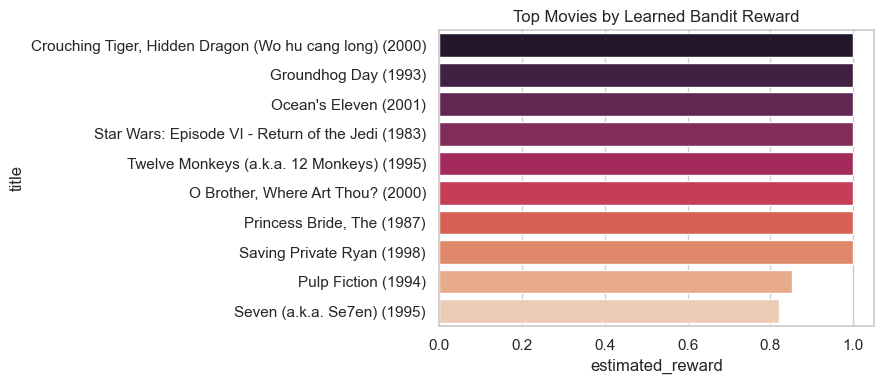

**Analysis:** Unlike static recommenders, the RL setup explicitly balances exploration and exploitation. The learned reward estimates show which movies appear most valuable once repeated recommendation-feedback loops are simulated.

In [12]:
rl_outputs = sol.run_rl(steps=2000)
display(rl_outputs['summary'])
display(rl_outputs['top_movies'])

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=rl_outputs['top_movies'], x='estimated_reward', y='title', ax=ax, palette='rocket')
ax.set_title('Top Movies by Learned Bandit Reward')
plt.tight_layout()
plt.show()

display(Markdown("**Analysis:** Unlike static recommenders, the RL setup explicitly balances exploration and exploitation. The learned reward estimates show which movies appear most valuable once repeated recommendation-feedback loops are simulated."))


## Task 10: Feature-Based Explanations for Content-Based Filtering

Show which content features contributed most to a recommendation, and use SHAP to provide a model-based local explanation.


,feature,contribution
0,Action,3.491892
1,Adventure,3.481884
2,Crime,3.447059
3,Romance,3.433333
4,Drama,3.387931


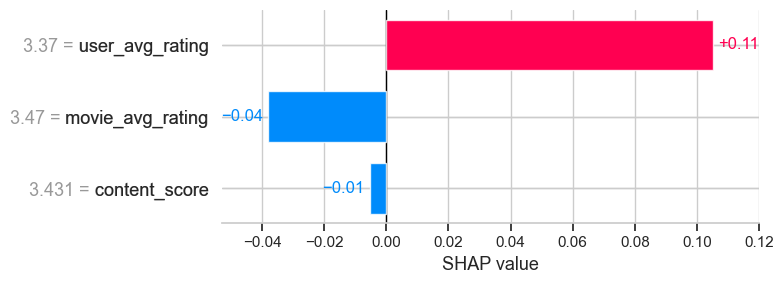

**Analysis:** The direct explanation identifies the dominant genre features behind the recommendation, while SHAP shows how the surrogate content model decomposes the predicted score into local feature contributions.

In [13]:
explained_movie = int(content_recs[0][0])
direct_explanation = sol.explain_content(demo_user, explained_movie)
display(direct_explanation)

shap_values = sol.shap_content(demo_user, explained_movie)
shap.plots.bar(shap_values[0], show=False)
plt.tight_layout()
plt.show()

display(Markdown("**Analysis:** The direct explanation identifies the dominant genre features behind the recommendation, while SHAP shows how the surrogate content model decomposes the predicted score into local feature contributions."))


## Task 11: Neighborhood-Based Explanations for Collaborative Filtering

Explain a recommendation in terms of similar users and similar items.


In [14]:
neighbor_movie = int(sol.recommend_item_cf(demo_user, top_n=1, k=30)[0][0])
user_neighbor_exp = sol.explain_user_neighbors(demo_user, neighbor_movie, k=5)
item_neighbor_exp = sol.explain_item_neighbors(demo_user, neighbor_movie, k=5)
display(user_neighbor_exp)
display(item_neighbor_exp)

display(Markdown("**Analysis:** Neighborhood explanations are usually the easiest to verbalize to end users because they map naturally to statements like 'users similar to you liked this' or 'because you liked these similar movies'."))


,neighbor_user,similarity,neighbor_rating
0,309551,0.270618,4.0
1,130884,0.249575,2.5
2,310406,0.234833,5.0
3,262371,0.234640,5.0
4,119812,0.231671,5.0


,movieId,title,similarity,user_rating
0,33794,Batman Begins (2005),0.508275,4.0
1,59315,Iron Man (2008),0.460004,4.0
2,91529,"Dark Knight Rises, The (2012)",0.421992,4.0
3,89745,"Avengers, The (2012)",0.389301,3.5
4,79132,Inception (2010),0.387787,4.5


**Analysis:** Neighborhood explanations are usually the easiest to verbalize to end users because they map naturally to statements like 'users similar to you liked this' or 'because you liked these similar movies'.

## Task 12: Model-Agnostic Explainability for the Neural Model

Use LIME to produce a local explanation for the neural recommender.


In [15]:
lime_exp = sol.lime_neural(demo_user, explained_movie)
lime_df = pd.DataFrame(lime_exp.as_list(), columns=['feature', 'weight'])
display(lime_df)

display(Markdown("**Analysis:** LIME approximates the neural recommender locally around one user-movie pair. The top weighted features indicate which user and movie metadata dimensions most influenced the prediction in that local neighborhood."))


,feature,weight
0,-6.93 < movie_movie_avg_rating <= 1.43,-0.561243
1,movie_genre_Musical <= -0.11,-0.436602
2,movie_genre_War <= -0.17,-0.306433
3,movie_genre_Crime > -0.29,0.300928
4,movie_genre_Mystery <= -0.22,-0.234040
5,movie_genre_Film-Noir <= -0.06,-0.218490
6,movie_genre_Fantasy <= -0.21,-0.215520
7,movie_genre_Children <= -0.23,-0.205142
8,movie_genre_Sci-Fi <= -0.24,-0.198055
9,-0.35 < movie_genre_Action <= 2.84,0.189786


**Analysis:** LIME approximates the neural recommender locally around one user-movie pair. The top weighted features indicate which user and movie metadata dimensions most influenced the prediction in that local neighborhood.

## Task 13: Evaluating Explainability and Final Model Comparison

Compare explanation styles, summarize their usefulness, and present a final model comparison table. Here the RMSE column is computed on a reproducible evaluation slice from the full-dataset core to keep the notebook executable.


,method,best_for,strength,limitation
0,Direct feature overlap,Content-based filtering,Highly interpretable,Misses hidden non-linear effects
1,SHAP,Feature attribution,Strong local explanations,Extra computation cost
2,Neighborhood explanation,Collaborative filtering,Easy to verbalize,Can inherit neighborhood bias
3,LIME,Neural models,Model-agnostic,Can vary across runs


,model,RMSE_sample,precision@10,recall@10,evaluated_users
8,Surprise SVD,0.811465,0.346667,0.124715,15
6,Item-CF (k=40),0.817783,0.393333,0.156362,15
5,Item-CF (k=20),0.825211,0.386667,0.147950,15
4,Item-CF (k=10),0.827903,0.373333,0.114928,15
2,User-CF (k=20),0.832688,0.360000,0.140319,15
3,User-CF (k=40),0.840857,0.366667,0.142901,15
1,User-CF (k=10),0.845529,0.333333,0.123090,15
7,Manual SVD,0.883687,0.420000,0.170268,15
9,Hybrid Meta-Model,0.890104,0.313333,0.118595,15
0,User-Profile Content Recommender,0.942817,0.000000,0.000000,15


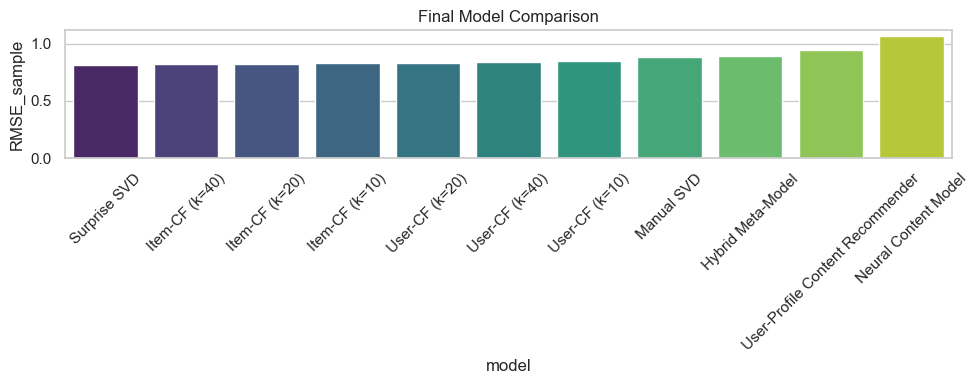

**Analysis:** Different explanation methods serve different audiences: feature-based explanations are intuitive, neighborhood-based explanations align with collaborative stories, and model-agnostic tools are helpful for complex learned recommenders. The final comparison table makes it easy to discuss the trade-off between predictive quality and interpretability across all assignment tasks.

In [16]:
explainability_table = pd.DataFrame([
    {'method': 'Direct feature overlap', 'best_for': 'Content-based filtering', 'strength': 'Highly interpretable', 'limitation': 'Misses hidden non-linear effects'},
    {'method': 'SHAP', 'best_for': 'Feature attribution', 'strength': 'Strong local explanations', 'limitation': 'Extra computation cost'},
    {'method': 'Neighborhood explanation', 'best_for': 'Collaborative filtering', 'strength': 'Easy to verbalize', 'limitation': 'Can inherit neighborhood bias'},
    {'method': 'LIME', 'best_for': 'Neural models', 'strength': 'Model-agnostic', 'limitation': 'Can vary across runs'},
])

final_comparison = pd.concat([
    content_metrics,
    user_cf_df,
    item_cf_df,
    svd_results,
    surprise_results,
    hybrid_results,
    neural_results,
], ignore_index=True)

display(explainability_table)
display(final_comparison.sort_values('RMSE_sample'))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=final_comparison.sort_values('RMSE_sample'), x='model', y='RMSE_sample', ax=ax, palette='viridis')
ax.set_title('Final Model Comparison')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

display(Markdown("**Analysis:** Different explanation methods serve different audiences: feature-based explanations are intuitive, neighborhood-based explanations align with collaborative stories, and model-agnostic tools are helpful for complex learned recommenders. The final comparison table makes it easy to discuss the trade-off between predictive quality and interpretability across all assignment tasks."))
